# 1. Análise Exploratória de Dados (EDA)

## Análise da satisfação dos consumidores — Olist

Este notebook corresponde à etapa de Análise Exploratória de Dados (EDA) do projeto.

A análise tem como objetivo investigar os principais fatores associados à satisfação e à insatisfação dos consumidores após a experiência de compra.

A partir da base analítica preparada na etapa anterior, serão exploradas características relacionadas a:

- avaliações dos consumidores;
- desempenho e atrasos nas entregas;
- valores dos pedidos e do frete;
- características dos pedidos;
- categorias de produtos;
- localização dos consumidores;
- comportamento temporal das compras.

Os resultados desta etapa serão utilizados para identificar padrões relevantes nos dados e orientar as etapas posteriores de modelagem preditiva e visualização.

In [ ]:
# Bibliotecas para manipulação e análise dos dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive conectado com sucesso.")

Mounted at /content/drive
Google Drive conectado com sucesso.


In [ ]:
from pathlib import Path

# Caminho da pasta com os dados processados
PROCESSED_PATH = Path(
    '/content/drive/MyDrive/semantix-data-project/data/processed'
)

# Arquivo da base analítica
arquivo_analitico = PROCESSED_PATH / 'olist_analytical_dataset.csv'

# Carregamento da base
df = pd.read_csv(
    arquivo_analitico,
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
)

print("Base analítica carregada com sucesso.")
print("Dimensão:", df.shape)

display(df.head())

Base analítica carregada com sucesso.
Dimensão: (96470, 34)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega_dias,diferenca_prazo_dias,atrasado,quantidade_itens,valor_produtos,valor_frete,quantidade_produtos_unicos,quantidade_vendedores,valor_pagamento,quantidade_pagamentos,max_parcelas,quantidade_formas_pagamento,review_score,categoria_principal,categoria_principal_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,insatisfeito,frete_percentual,valor_total_pedido,ano_compra,mes_compra,dia_semana_compra,hora_compra
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.44,-7.11,0,1,29.99,8.72,1,1,38.71,3.00,1.00,2.00,4.00,utilidades_domesticas,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,0.00,29.08,38.71,2017,10,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.78,-5.36,0,1,118.70,22.76,1,1,141.46,1.00,1.00,1.00,4.00,perfumaria,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,0.00,19.17,141.46,2018,7,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.39,-17.25,0,1,159.90,19.22,1,1,179.12,1.00,3.00,1.00,5.00,automotivo,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,0.00,12.02,179.12,2018,8,Wednesday,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.21,-12.98,0,1,45.00,27.20,1,1,72.20,1.00,1.00,1.00,5.00,pet_shop,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,0.00,60.44,72.20,2017,11,Saturday,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.87,-9.24,0,1,19.90,8.72,1,1,28.62,1.00,1.00,1.00,5.00,papelaria,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,0.00,43.82,28.62,2018,2,Tuesday,21


## 2. Visão geral da base analítica

Antes de iniciar as análises específicas, será realizada uma inspeção geral da base para confirmar sua estrutura, os tipos das variáveis e a qualidade dos dados carregados.

Esta etapa permite verificar se a base preparada anteriormente está adequada para a análise exploratória.

In [ ]:
print("Dimensão da base:")
print(f"{df.shape[0]} pedidos e {df.shape[1]} variáveis")

print("\nTipos das variáveis:")
df.info()

Dimensão da base:
96470 pedidos e 34 variáveis

Tipos das variáveis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   customer_id                    96470 non-null  object        
 2   order_status                   96470 non-null  object        
 3   order_purchase_timestamp       96470 non-null  datetime64[ns]
 4   order_approved_at              96456 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96469 non-null  datetime64[ns]
 6   order_delivered_customer_date  96470 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 8   tempo_entrega_dias             96470 non-null  float64       
 9   diferenca_prazo_dias           96470 non-null  float64       
 10  atrasado     

### Validação inicial da base

A base analítica contém 96.470 pedidos e 34 variáveis, mantendo a unidade de análise definida na etapa de preparação dos dados.

Os tipos das variáveis estão adequados às análises propostas, incluindo variáveis temporais, numéricas e categóricas.

Foram identificados 646 pedidos sem avaliação (`review_score`), correspondentes aos registros que não possuem classificação na variável-alvo `insatisfeito`. Esses pedidos poderão permanecer nas análises descritivas quando a avaliação do consumidor não for necessária, mas serão desconsiderados nas análises que dependem diretamente da satisfação.

Os demais valores ausentes apresentam baixa ocorrência e serão considerados de acordo com as variáveis utilizadas em cada análise.

## 3. Análise da satisfação dos consumidores

Nesta etapa será analisada a distribuição das avaliações atribuídas pelos consumidores aos pedidos entregues.

Inicialmente, será observada a distribuição das notas de 1 a 5 estrelas. Em seguida, será analisada a variável-alvo `insatisfeito`, definida anteriormente como:

- **0 — Não insatisfeito:** avaliações de 3 a 5 estrelas;
- **1 — Insatisfeito:** avaliações de 1 ou 2 estrelas.

Essa análise permitirá compreender a distribuição da satisfação dos consumidores na base e verificar o equilíbrio entre as classes da variável-alvo.

In [ ]:
# Distribuição das avaliações de 1 a 5 estrelas

distribuicao_notas = (
    df['review_score']
    .dropna()
    .value_counts()
    .sort_index()
    .rename_axis('review_score')
    .reset_index(name='quantidade')
)

distribuicao_notas['percentual'] = (
    distribuicao_notas['quantidade']
    / distribuicao_notas['quantidade'].sum()
    * 100
).round(2)

display(distribuicao_notas)

,review_score,quantidade,percentual
0,1.00,9351,9.76
1,2.00,2921,3.05
2,3.00,7916,8.26
3,4.00,18888,19.71
4,5.00,56748,59.22


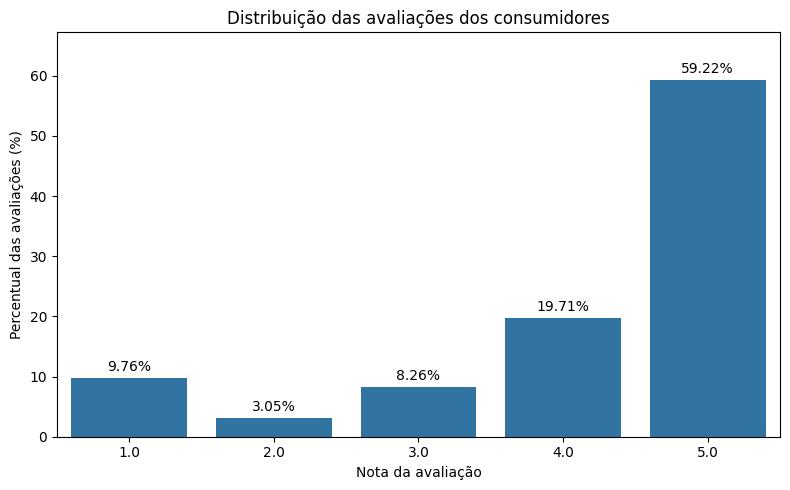

In [ ]:
# Visualização da distribuição das avaliações

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=distribuicao_notas,
    x='review_score',
    y='percentual'
)

plt.title('Distribuição das avaliações dos consumidores')
plt.xlabel('Nota da avaliação')
plt.ylabel('Percentual das avaliações (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.ylim(0, distribuicao_notas['percentual'].max() + 8)
plt.tight_layout()
plt.show()

### Interpretação da distribuição das avaliações

A distribuição das avaliações apresenta forte concentração nas notas mais altas. A nota 5 representa 59,22% das avaliações, seguida pela nota 4, com 19,71%.

Em conjunto, as avaliações de 4 e 5 estrelas correspondem a 78,93% das avaliações válidas, indicando predominância de experiências avaliadas positivamente pelos consumidores.

Por outro lado, as avaliações de 1 e 2 estrelas representam 12,81% das avaliações válidas. Embora sejam proporcionalmente menores, esses registros constituem o principal grupo de interesse deste projeto, pois correspondem aos consumidores classificados como insatisfeitos.

A distribuição também evidencia um desequilíbrio entre as classes de satisfação, aspecto que deverá ser considerado posteriormente na etapa de modelagem preditiva.

In [ ]:
# Distribuição da variável-alvo entre os pedidos avaliados

distribuicao_insatisfacao = (
    df['insatisfeito']
    .dropna()
    .value_counts()
    .sort_index()
    .rename_axis('insatisfeito')
    .reset_index(name='quantidade')
)

distribuicao_insatisfacao['percentual'] = (
    distribuicao_insatisfacao['quantidade']
    / distribuicao_insatisfacao['quantidade'].sum()
    * 100
).round(2)

distribuicao_insatisfacao['classificacao'] = (
    distribuicao_insatisfacao['insatisfeito']
    .map({
        0: 'Não insatisfeito',
        1: 'Insatisfeito'
    })
)

display(
    distribuicao_insatisfacao[
        ['classificacao', 'quantidade', 'percentual']
    ]
)

,classificacao,quantidade,percentual
0,Não insatisfeito,83552,87.19
1,Insatisfeito,12272,12.81


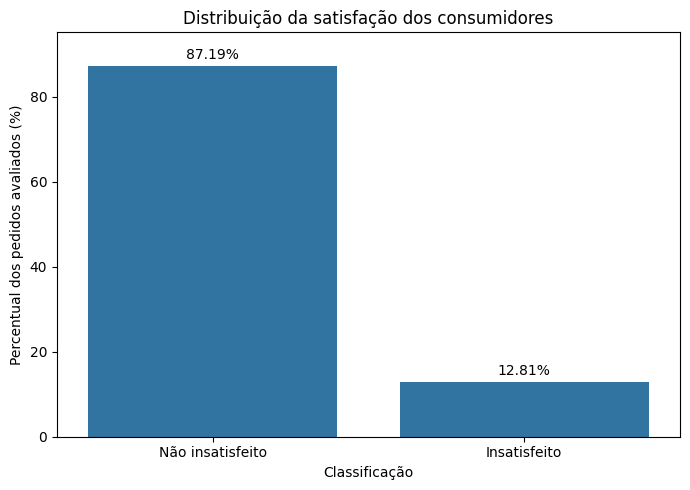

In [ ]:
# Visualização da distribuição da variável-alvo

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=distribuicao_insatisfacao,
    x='classificacao',
    y='percentual'
)

plt.title('Distribuição da satisfação dos consumidores')
plt.xlabel('Classificação')
plt.ylabel('Percentual dos pedidos avaliados (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.ylim(0, distribuicao_insatisfacao['percentual'].max() + 8)
plt.tight_layout()
plt.show()

### Interpretação da variável-alvo

Entre os pedidos que possuem avaliação, 87,19% foram classificados como não insatisfeitos, enquanto 12,81% foram classificados como insatisfeitos.

A diferença entre as proporções evidencia um desbalanceamento entre as classes da variável-alvo, com predominância dos consumidores não insatisfeitos.

Esse aspecto será relevante principalmente na etapa de modelagem preditiva, pois a classe de maior interesse para o projeto — consumidores insatisfeitos — representa uma parcela menor dos registros disponíveis.

Nas análises exploratórias seguintes, serão investigados fatores que podem estar associados à insatisfação, buscando identificar características que diferenciem os dois grupos de consumidores.

## 4. Relação entre desempenho da entrega e insatisfação

O desempenho logístico pode exercer influência importante sobre a experiência do consumidor. Nesta etapa, será investigada a relação entre as características da entrega e a ocorrência de insatisfação.

Serão analisados principalmente:

- o cumprimento do prazo estimado de entrega;
- o tempo necessário para a entrega do pedido;
- a diferença entre a data efetiva e a data estimada de entrega.

Inicialmente, será comparada a proporção de consumidores insatisfeitos entre pedidos entregues dentro do prazo e pedidos entregues com atraso.

In [ ]:
# Relação entre atraso na entrega e insatisfação

analise_atraso = (
    df[
        df['insatisfeito'].notna()
    ]
    .groupby('atrasado')['insatisfeito']
    .agg(
        quantidade_pedidos='count',
        quantidade_insatisfeitos='sum',
        percentual_insatisfeitos='mean'
    )
    .reset_index()
)

analise_atraso['percentual_insatisfeitos'] = (
    analise_atraso['percentual_insatisfeitos'] * 100
).round(2)

analise_atraso['situacao_entrega'] = (
    analise_atraso['atrasado']
    .map({
        0: 'Dentro do prazo',
        1: 'Atrasado'
    })
)

display(
    analise_atraso[
        [
            'situacao_entrega',
            'quantidade_pedidos',
            'quantidade_insatisfeitos',
            'percentual_insatisfeitos'
        ]
    ]
)

,situacao_entrega,quantidade_pedidos,quantidade_insatisfeitos,percentual_insatisfeitos
0,Dentro do prazo,88163,8130.00,9.22
1,Atrasado,7661,4142.00,54.07


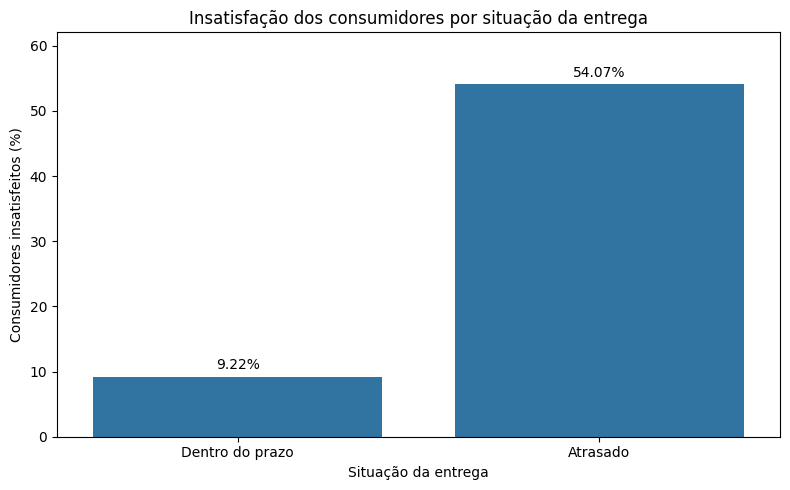

In [ ]:
# Visualização da relação entre atraso e insatisfação

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=analise_atraso,
    x='situacao_entrega',
    y='percentual_insatisfeitos'
)

plt.title('Insatisfação dos consumidores por situação da entrega')
plt.xlabel('Situação da entrega')
plt.ylabel('Consumidores insatisfeitos (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.ylim(
    0,
    analise_atraso['percentual_insatisfeitos'].max() + 8
)

plt.tight_layout()
plt.show()

### Interpretação da relação entre atraso e insatisfação

A situação da entrega apresenta uma associação expressiva com a insatisfação dos consumidores.

Entre os pedidos entregues dentro do prazo, 9,22% dos consumidores foram classificados como insatisfeitos. Nos pedidos entregues com atraso, esse percentual aumenta para 54,07%.

Isso significa que a proporção de consumidores insatisfeitos é aproximadamente 5,9 vezes maior entre os pedidos atrasados, indicando uma forte associação entre atraso na entrega e insatisfação.

Esse resultado sugere que o desempenho logístico é um fator relevante para a experiência do consumidor e deverá receber atenção nas etapas posteriores da análise e da modelagem preditiva. A relação observada, entretanto, representa uma associação entre as variáveis e não permite, isoladamente, estabelecer uma relação de causalidade.

In [ ]:
# Tempo de entrega de acordo com a satisfação do consumidor

tempo_entrega_satisfacao = (
    df[
        df['insatisfeito'].notna()
    ]
    .groupby('insatisfeito')['tempo_entrega_dias']
    .agg(
        quantidade='count',
        media='mean',
        mediana='median',
        minimo='min',
        maximo='max'
    )
    .reset_index()
)

tempo_entrega_satisfacao['classificacao'] = (
    tempo_entrega_satisfacao['insatisfeito']
    .map({
        0: 'Não insatisfeito',
        1: 'Insatisfeito'
    })
)

for coluna in ['media', 'mediana', 'minimo', 'maximo']:
    tempo_entrega_satisfacao[coluna] = (
        tempo_entrega_satisfacao[coluna].round(2)
    )

display(
    tempo_entrega_satisfacao[
        [
            'classificacao',
            'quantidade',
            'media',
            'mediana',
            'minimo',
            'maximo'
        ]
    ]
)

,classificacao,quantidade,media,mediana,minimo,maximo
0,Não insatisfeito,83552,11.39,9.87,0.53,194.85
1,Insatisfeito,12272,20.21,15.72,0.86,208.35


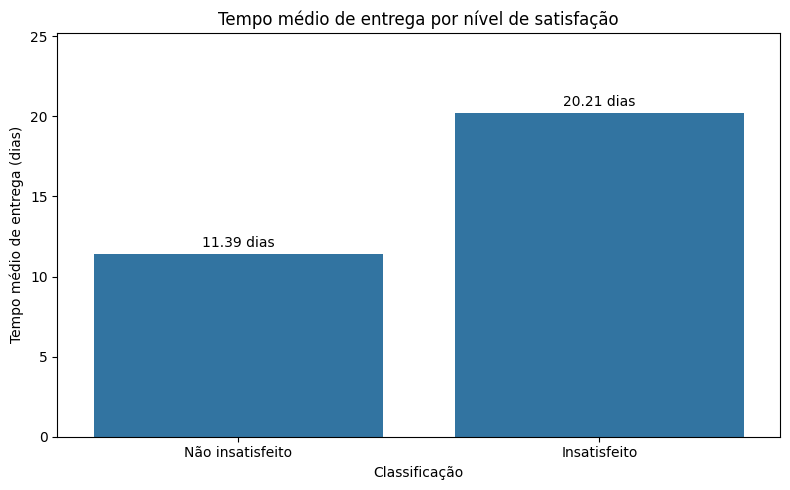

In [ ]:
# Comparação do tempo médio de entrega por nível de satisfação

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tempo_entrega_satisfacao,
    x='classificacao',
    y='media'
)

plt.title('Tempo médio de entrega por nível de satisfação')
plt.xlabel('Classificação')
plt.ylabel('Tempo médio de entrega (dias)')

# Exibir os valores sobre as barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f dias', padding=3)

plt.ylim(0, tempo_entrega_satisfacao['media'].max() + 5)

plt.tight_layout()
plt.show()

### Interpretação do tempo de entrega e satisfação

Os consumidores classificados como insatisfeitos apresentaram maior tempo médio de entrega em comparação aos consumidores não insatisfeitos.

Entre os consumidores não insatisfeitos, o tempo médio de entrega foi de 11,39 dias, enquanto entre os consumidores insatisfeitos a média foi de 20,21 dias.

A diferença de aproximadamente 8,82 dias reforça a associação observada anteriormente entre o desempenho da entrega e a insatisfação dos consumidores. No entanto, essa relação deve ser interpretada como uma associação entre as variáveis, não sendo suficiente, isoladamente, para estabelecer uma relação de causalidade.

### Diferença entre o prazo estimado e a entrega efetiva

Além do tempo total de entrega, será analisada a diferença entre a data efetiva de entrega e a data estimada informada ao consumidor.

A variável `diferenca_prazo_dias` permite observar com maior detalhe o desempenho em relação ao prazo previsto, considerando não apenas a ocorrência de atraso, mas também a magnitude dessa diferença.

Será comparado o comportamento dessa variável entre consumidores insatisfeitos e não insatisfeitos, buscando verificar se maiores diferenças em relação ao prazo estimado estão associadas à insatisfação.

In [ ]:
# Diferença em relação ao prazo estimado por nível de satisfação

diferenca_prazo_satisfacao = (
    df.dropna(subset=['insatisfeito', 'diferenca_prazo_dias'])
    .groupby('insatisfeito')['diferenca_prazo_dias']
    .agg(
        quantidade='count',
        media='mean',
        mediana='median',
        minimo='min',
        maximo='max'
    )
    .reset_index()
)

diferenca_prazo_satisfacao['classificacao'] = (
    diferenca_prazo_satisfacao['insatisfeito']
    .map({
        0: 'Não insatisfeito',
        1: 'Insatisfeito'
    })
)

for coluna in ['media', 'mediana', 'minimo', 'maximo']:
    diferenca_prazo_satisfacao[coluna] = (
        diferenca_prazo_satisfacao[coluna].round(2)
    )

display(
    diferenca_prazo_satisfacao[
        [
            'classificacao',
            'quantidade',
            'media',
            'mediana',
            'minimo',
            'maximo'
        ]
    ]
)

,classificacao,quantidade,media,mediana,minimo,maximo
0,Não insatisfeito,83552,-12.21,-12.19,-146.02,162.72
1,Insatisfeito,12272,-4.43,-7.25,-68.45,188.98


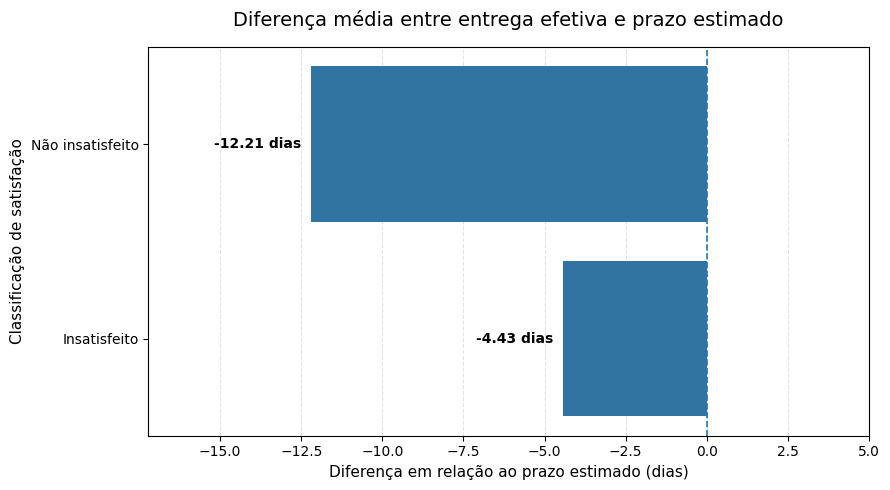

In [ ]:
# Diferença média entre entrega efetiva e prazo estimado por satisfação

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=diferenca_prazo_satisfacao,
    y='classificacao',
    x='media',
    orient='h'
)

# Linha de referência do prazo estimado
ax.axvline(
    x=0,
    linewidth=1.2,
    linestyle='--'
)

# Título e eixos
ax.set_title(
    'Diferença média entre entrega efetiva e prazo estimado',
    fontsize=14,
    pad=15
)

ax.set_xlabel(
    'Diferença em relação ao prazo estimado (dias)',
    fontsize=11
)

ax.set_ylabel(
    'Classificação de satisfação',
    fontsize=11
)

# Grade apenas no eixo X
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.35
)

ax.set_axisbelow(True)

# Espaço suficiente para barras e rótulos
menor_valor = diferenca_prazo_satisfacao['media'].min()
maior_valor = diferenca_prazo_satisfacao['media'].max()

ax.set_xlim(
    menor_valor - 5,
    max(5, maior_valor + 5)
)

# Adicionar os valores nas extremidades das barras
for barra in ax.patches:
    valor = barra.get_width()
    y = barra.get_y() + barra.get_height() / 2

    if valor < 0:
        ax.text(
            valor - 0.3,
            y,
            f'{valor:.2f} dias',
            va='center',
            ha='right',
            fontweight='bold'
        )
    else:
        ax.text(
            valor + 0.3,
            y,
            f'{valor:.2f} dias',
            va='center',
            ha='left',
            fontweight='bold'
        )

# Manter todos os contornos dos eixos visíveis
for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()


In [ ]:
# Resumo dos resultados da diferença em relação ao prazo estimado

for _, linha in diferenca_prazo_satisfacao.iterrows():
    classificacao = linha['classificacao']
    media = linha['media']
    mediana = linha['mediana']

    if media < 0:
        situacao_media = f"{abs(media):.2f} dias antes do prazo"
    elif media > 0:
        situacao_media = f"{media:.2f} dias após o prazo"
    else:
        situacao_media = "na data estimada"

    if mediana < 0:
        situacao_mediana = f"{abs(mediana):.2f} dias antes do prazo"
    elif mediana > 0:
        situacao_mediana = f"{mediana:.2f} dias após o prazo"
    else:
        situacao_mediana = "na data estimada"

    print(f"{classificacao}:")
    print(f"  Média: {situacao_media}")
    print(f"  Mediana: {situacao_mediana}")
    print()

Não insatisfeito:
  Média: 12.21 dias antes do prazo
  Mediana: 12.19 dias antes do prazo

Insatisfeito:
  Média: 4.43 dias antes do prazo
  Mediana: 7.25 dias antes do prazo



### Interpretação da diferença em relação ao prazo estimado

Os dois grupos apresentaram, em média, entregas realizadas antes da data estimada. Entretanto, existe uma diferença relevante entre eles.

Entre os consumidores não insatisfeitos, os pedidos foram entregues, em média, **12,21 dias antes do prazo estimado**, com mediana de **12,19 dias de antecedência**.

Entre os consumidores insatisfeitos, a antecedência média foi de apenas **4,43 dias**, com mediana de **7,25 dias**.

Portanto, embora a antecipação da entrega seja observada nos dois grupos, os consumidores não insatisfeitos receberam seus pedidos com uma margem de antecedência consideravelmente maior. Esse resultado complementa as análises anteriores e reforça a associação entre desempenho logístico e satisfação do consumidor.

É importante destacar que a média dos consumidores insatisfeitos é inferior à mediana, o que sugere a influência de entregas mais tardias e atrasos extremos sobre a média desse grupo.

## 5. Relação entre características financeiras do pedido e insatisfação

Além do desempenho logístico, características financeiras da compra também podem estar associadas à experiência do consumidor.

Nesta etapa, serão comparados consumidores insatisfeitos e não insatisfeitos em relação a:

- valor dos produtos;
- valor do frete;
- valor total do pedido;
- participação do frete no valor dos produtos.

O objetivo é verificar se existem diferenças relevantes no perfil financeiro dos pedidos entre os dois grupos.

In [ ]:
# Comparação das características financeiras por nível de satisfação

financeiro_satisfacao = (
    df[
        df['insatisfeito'].notna()
    ]
    .groupby('insatisfeito')
    .agg(
        quantidade_pedidos=('order_id', 'count'),
        valor_produtos_medio=('valor_produtos', 'mean'),
        valor_frete_medio=('valor_frete', 'mean'),
        valor_total_medio=('valor_total_pedido', 'mean'),
        frete_percentual_medio=('frete_percentual', 'mean')
    )
    .reset_index()
)

financeiro_satisfacao['classificacao'] = (
    financeiro_satisfacao['insatisfeito']
    .map({
        0: 'Não insatisfeito',
        1: 'Insatisfeito'
    })
)

colunas_numericas = [
    'valor_produtos_medio',
    'valor_frete_medio',
    'valor_total_medio',
    'frete_percentual_medio'
]

financeiro_satisfacao[colunas_numericas] = (
    financeiro_satisfacao[colunas_numericas].round(2)
)

display(
    financeiro_satisfacao[
        [
            'classificacao',
            'quantidade_pedidos',
            'valor_produtos_medio',
            'valor_frete_medio',
            'valor_total_medio',
            'frete_percentual_medio'
        ]
    ]
)

,classificacao,quantidade_pedidos,valor_produtos_medio,valor_frete_medio,valor_total_medio,frete_percentual_medio
0,Não insatisfeito,83552,133.41,22.04,155.45,30.66
1,Insatisfeito,12272,159.89,27.71,187.60,32.08


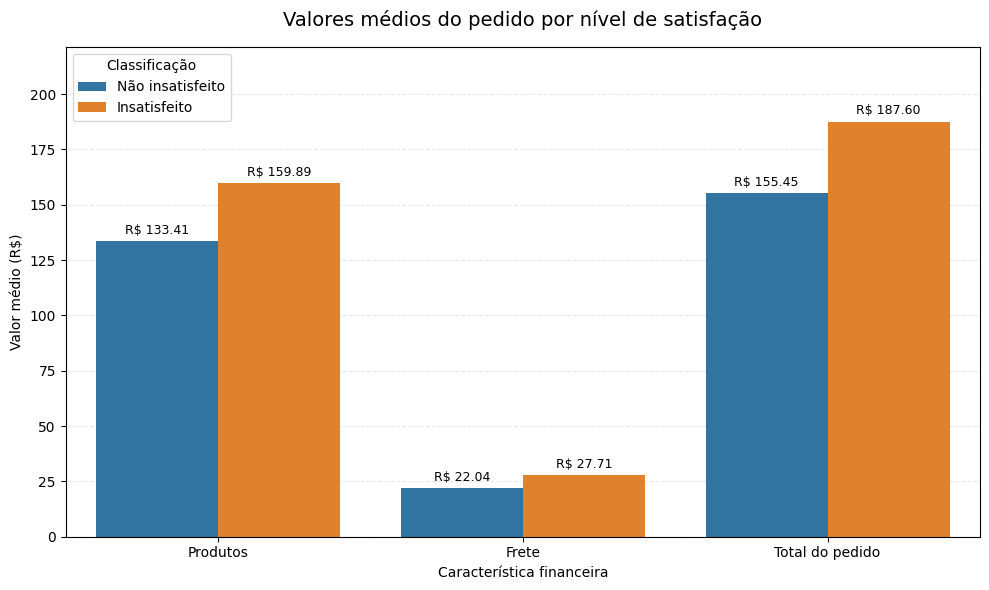

In [ ]:
# Preparação dos dados para comparação das métricas financeiras

financeiro_grafico = financeiro_satisfacao[
    [
        'classificacao',
        'valor_produtos_medio',
        'valor_frete_medio',
        'valor_total_medio'
    ]
].melt(
    id_vars='classificacao',
    var_name='metrica',
    value_name='valor_medio'
)

financeiro_grafico['metrica'] = financeiro_grafico['metrica'].map({
    'valor_produtos_medio': 'Produtos',
    'valor_frete_medio': 'Frete',
    'valor_total_medio': 'Total do pedido'
})

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=financeiro_grafico,
    x='metrica',
    y='valor_medio',
    hue='classificacao'
)

ax.set_title(
    'Valores médios do pedido por nível de satisfação',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Característica financeira')
ax.set_ylabel('Valor médio (R$)')

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

# Valores sobre as barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='R$ %.2f',
        padding=3,
        fontsize=9
    )

ax.legend(
    title='Classificação',
    frameon=True
)

plt.ylim(
    0,
    financeiro_grafico['valor_medio'].max() * 1.18
)

plt.tight_layout()
plt.show()

### Interpretação das características financeiras

Os consumidores insatisfeitos apresentam valores médios superiores em todas as características financeiras analisadas.

O valor médio dos produtos foi de **R\$ 159,89** entre os consumidores insatisfeitos, frente a **R\$ 133,41** entre os não insatisfeitos. O frete médio também foi superior, passando de **R\$ 22,04** para **R\$ 27,71**.

Como consequência, o valor total médio dos pedidos foi de **R\$ 187,60** entre os consumidores insatisfeitos, comparado a **R\$ 155,45** entre os não insatisfeitos.

A participação média do frete sobre o valor dos produtos apresentou diferença menor: **32,08%** entre os insatisfeitos e **30,66%** entre os não insatisfeitos. Dessa forma, os resultados sugerem maior associação da insatisfação com os valores absolutos do pedido e do frete do que com o peso proporcional do frete na compra.

Essas diferenças representam associações observadas nos dados e não permitem, isoladamente, concluir que valores mais elevados sejam responsáveis pela insatisfação.

### Complexidade do pedido e insatisfação

Além dos aspectos financeiros, a estrutura do pedido também pode estar associada à experiência do consumidor.

Nesta etapa, serão analisadas a quantidade de itens e a quantidade de vendedores envolvidos em cada pedido, buscando verificar se pedidos mais complexos apresentam diferenças nos níveis de insatisfação.

In [ ]:
# Comparação da complexidade dos pedidos por nível de satisfação

complexidade_satisfacao = (
    df[
        df['insatisfeito'].notna()
    ]
    .groupby('insatisfeito')
    .agg(
        quantidade_pedidos=('order_id', 'count'),
        itens_media=('quantidade_itens', 'mean'),
        itens_mediana=('quantidade_itens', 'median'),
        vendedores_media=('quantidade_vendedores', 'mean'),
        vendedores_mediana=('quantidade_vendedores', 'median')
    )
    .reset_index()
)

complexidade_satisfacao['classificacao'] = (
    complexidade_satisfacao['insatisfeito']
    .map({
        0: 'Não insatisfeito',
        1: 'Insatisfeito'
    })
)

colunas = [
    'itens_media',
    'itens_mediana',
    'vendedores_media',
    'vendedores_mediana'
]

complexidade_satisfacao[colunas] = (
    complexidade_satisfacao[colunas].round(2)
)

display(
    complexidade_satisfacao[
        [
            'classificacao',
            'quantidade_pedidos',
            'itens_media',
            'itens_mediana',
            'vendedores_media',
            'vendedores_mediana'
        ]
    ]
)

,classificacao,quantidade_pedidos,itens_media,itens_mediana,vendedores_media,vendedores_mediana
0,Não insatisfeito,83552,1.12,1.00,1.01,1.00
1,Insatisfeito,12272,1.32,1.00,1.05,1.00


### Interpretação da complexidade dos pedidos

Os consumidores insatisfeitos apresentaram uma quantidade média de itens ligeiramente superior, com **1,32 item por pedido**, frente a **1,12** entre os não insatisfeitos. Entretanto, a mediana foi de **1 item** em ambos os grupos, indicando que pedidos com apenas um item predominam independentemente da classificação de satisfação.

Em relação à quantidade de vendedores, a diferença foi ainda menor. Os pedidos de consumidores insatisfeitos apresentaram média de **1,05 vendedor**, enquanto os não insatisfeitos registraram média de **1,01**, com mediana de **1 vendedor** nos dois grupos.

Dessa forma, a análise descritiva não evidencia diferenças expressivas na quantidade de vendedores entre os grupos. A quantidade de itens apresenta uma diferença moderada nas médias, mas a igualdade das medianas indica que esse resultado deve ser interpretado com cautela.

## 6. Categoria do produto e insatisfação

A experiência do consumidor também pode variar de acordo com a categoria dos produtos adquiridos.

Nesta etapa, será calculada a taxa de insatisfação por categoria, buscando identificar segmentos que apresentam maior concentração proporcional de consumidores insatisfeitos.

Para evitar conclusões baseadas em categorias com baixo volume de observações, o ranking principal considerará apenas categorias com pelo menos 100 pedidos avaliados.

In [ ]:
# Taxa de insatisfação por categoria de produto

categoria_insatisfacao = (
    df[
        df['insatisfeito'].notna()
    ]
    .groupby('categoria_principal')
    .agg(
        quantidade_pedidos=('order_id', 'count'),
        quantidade_insatisfeitos=('insatisfeito', 'sum'),
        taxa_insatisfacao=('insatisfeito', 'mean')
    )
    .reset_index()
)

categoria_insatisfacao['taxa_insatisfacao'] = (
    categoria_insatisfacao['taxa_insatisfacao'] * 100
).round(2)

# Manter categorias com volume suficiente para comparação
categorias_relevantes = (
    categoria_insatisfacao[
        categoria_insatisfacao['quantidade_pedidos'] >= 100
    ]
    .sort_values(
        'taxa_insatisfacao',
        ascending=False
    )
    .reset_index(drop=True)
)

# Top 10 categorias com maior taxa de insatisfação
top10_categorias_insatisfacao = (
    categorias_relevantes
    .head(10)
    .copy()
)

display(top10_categorias_insatisfacao)

,categoria_principal,quantidade_pedidos,quantidade_insatisfeitos,taxa_insatisfacao
0,fashion_roupa_masculina,105,24.00,22.86
1,moveis_escritorio,1241,272.00,21.92
2,audio,341,73.00,21.41
3,casa_conforto,368,66.00,17.93
4,telefonia_fixa,209,35.00,16.75
5,sem_categoria,1349,223.00,16.53
6,fashion_underwear_e_moda_praia,116,19.00,16.38
7,casa_construcao,470,75.00,15.96
8,cama_mesa_banho,9090,1438.00,15.82
9,construcao_ferramentas_seguranca,153,24.00,15.69


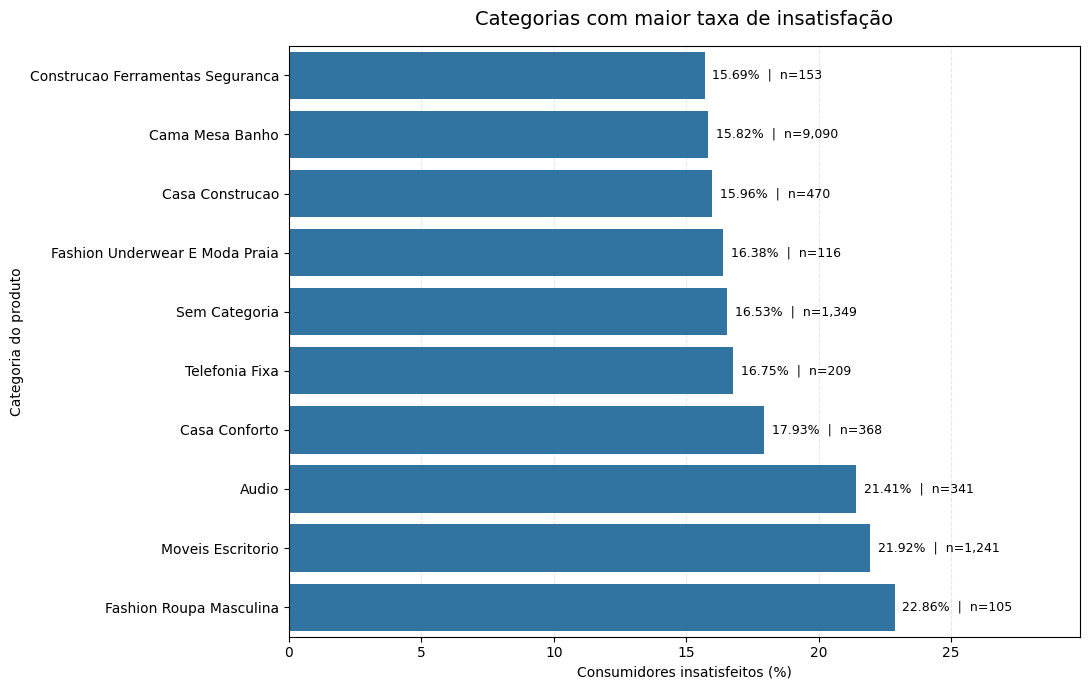

In [ ]:
# Ranking das categorias com maior taxa de insatisfação

grafico_categorias = (
    top10_categorias_insatisfacao
    .sort_values('taxa_insatisfacao', ascending=True)
    .copy()
)

# Nomes mais legíveis para apresentação
grafico_categorias['categoria_exibicao'] = (
    grafico_categorias['categoria_principal']
    .str.replace('_', ' ', regex=False)
    .str.title()
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=grafico_categorias,
    y='categoria_exibicao',
    x='taxa_insatisfacao',
    orient='h'
)

ax.set_title(
    'Categorias com maior taxa de insatisfação',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Consumidores insatisfeitos (%)')
ax.set_ylabel('Categoria do produto')

# Grade para facilitar a comparação
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

# Espaço para os rótulos
ax.set_xlim(
    0,
    grafico_categorias['taxa_insatisfacao'].max() + 7
)

# Taxa + número de pedidos no final de cada barra
for barra, (_, linha) in zip(
    ax.patches,
    grafico_categorias.iterrows()
):
    valor = barra.get_width()
    y = barra.get_y() + barra.get_height() / 2

    ax.text(
        valor + 0.3,
        y,
        f"{valor:.2f}%  |  n={int(linha['quantidade_pedidos']):,}",
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Interpretação da insatisfação por categoria

A taxa de insatisfação apresenta diferenças relevantes entre as categorias de produtos analisadas.

Entre as categorias com pelo menos 100 pedidos avaliados, **Fashion Roupa Masculina** apresentou a maior taxa de insatisfação, com **22,86%**, seguida por **Móveis Escritório (21,92%)** e **Áudio (21,41%)**.

O volume de pedidos, entretanto, deve ser considerado em conjunto com a taxa de insatisfação. Fashion Roupa Masculina possui apenas 105 pedidos avaliados, enquanto Móveis Escritório apresenta 1.241 pedidos, tornando a elevada taxa observada nesta última categoria especialmente relevante do ponto de vista operacional.

Também se destaca **Cama Mesa Banho**, que apresenta taxa de insatisfação de **15,82%** em um volume de **9.090 pedidos avaliados**. Embora sua taxa seja inferior às primeiras posições do ranking, o elevado volume faz com que a categoria concentre 1.438 consumidores insatisfeitos.

A categoria `sem_categoria` também aparece entre as maiores taxas de insatisfação. Entretanto, por representar registros sem classificação de produto, esse resultado deve ser interpretado separadamente das categorias comerciais propriamente ditas.

Os resultados indicam que a categoria do produto pode contribuir para diferenciar os perfis de satisfação, mas as taxas observadas representam associações descritivas e devem ser analisadas em conjunto com os demais fatores do pedido.

## 7. Distribuição geográfica da insatisfação

A localização do consumidor pode estar associada a diferenças na experiência de compra, especialmente em um contexto de comércio eletrônico no qual distância, infraestrutura logística e prazo de entrega podem variar regionalmente.

Nesta etapa, será analisada a taxa de insatisfação por estado do cliente, considerando também o volume de pedidos avaliados em cada localidade.

O objetivo é identificar possíveis diferenças regionais na satisfação dos consumidores, sem atribuir causalidade à localização geográfica.

In [ ]:
# Taxa de insatisfação por estado do cliente

estado_insatisfacao = (
    df[
        df['insatisfeito'].notna()
    ]
    .groupby('customer_state')
    .agg(
        quantidade_pedidos=('order_id', 'count'),
        quantidade_insatisfeitos=('insatisfeito', 'sum'),
        taxa_insatisfacao=('insatisfeito', 'mean')
    )
    .reset_index()
)

estado_insatisfacao['taxa_insatisfacao'] = (
    estado_insatisfacao['taxa_insatisfacao'] * 100
).round(2)

estado_insatisfacao = (
    estado_insatisfacao
    .sort_values(
        'taxa_insatisfacao',
        ascending=False
    )
    .reset_index(drop=True)
)

display(estado_insatisfacao)

,customer_state,quantidade_pedidos,quantidade_insatisfeitos,taxa_insatisfacao
0,AL,394,84.00,21.32
1,MA,712,142.00,19.94
2,SE,334,63.00,18.86
3,RJ,12211,2238.00,18.33
4,PA,933,167.00,17.90
5,CE,1273,218.00,17.12
6,BA,3229,549.00,17.00
7,PI,471,76.00,16.14
8,AC,80,12.00,15.00
9,PB,512,76.00,14.84


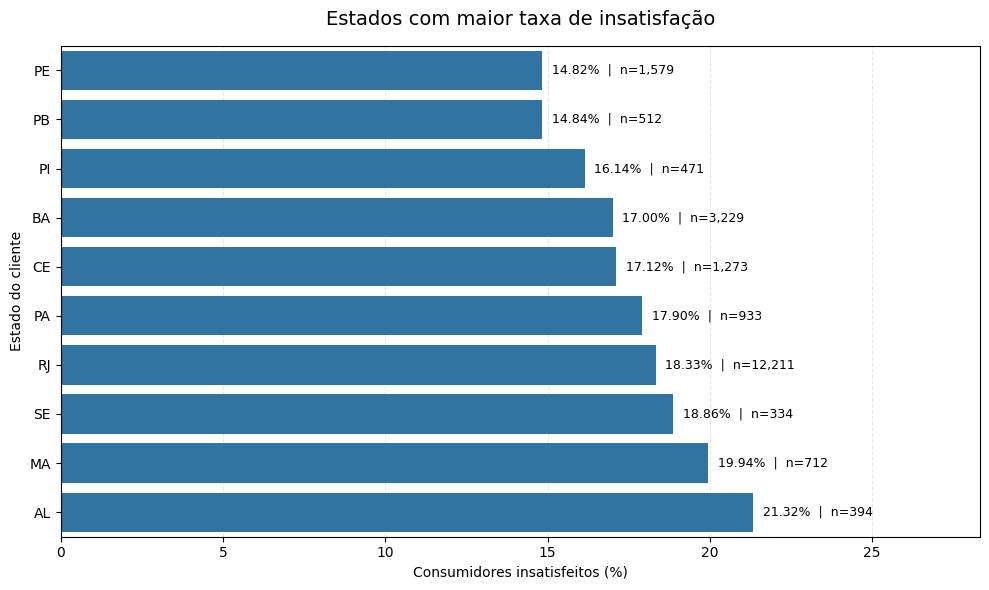

In [ ]:
# Estados com volume mínimo para comparação
estados_relevantes = (
    estado_insatisfacao[
        estado_insatisfacao['quantidade_pedidos'] >= 300
    ]
    .copy()
)

# Top 10 estados com maior taxa de insatisfação
top10_estados = (
    estados_relevantes
    .nlargest(10, 'taxa_insatisfacao')
    .sort_values('taxa_insatisfacao')
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top10_estados,
    y='customer_state',
    x='taxa_insatisfacao',
    orient='h'
)

ax.set_title(
    'Estados com maior taxa de insatisfação',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Consumidores insatisfeitos (%)')
ax.set_ylabel('Estado do cliente')

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

ax.set_xlim(
    0,
    top10_estados['taxa_insatisfacao'].max() + 7
)

# Taxa e volume ao final de cada barra
for barra, (_, linha) in zip(
    ax.patches,
    top10_estados.iterrows()
):
    valor = barra.get_width()
    y = barra.get_y() + barra.get_height() / 2

    ax.text(
        valor + 0.3,
        y,
        f"{valor:.2f}%  |  n={int(linha['quantidade_pedidos']):,}",
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Interpretação da distribuição geográfica

A taxa de insatisfação apresenta diferenças relevantes entre os estados analisados.

Considerando estados com pelo menos 300 pedidos avaliados, **Alagoas (AL)** apresentou a maior taxa de insatisfação, com **21,32%**, seguido por **Maranhão (MA), com 19,94%**, e **Sergipe (SE), com 18,86%**.

Entretanto, o volume de pedidos deve ser considerado juntamente com a taxa. Nesse aspecto, destaca-se o **Rio de Janeiro (RJ)**, que apresenta taxa de insatisfação de **18,33%** em uma base de **12.211 pedidos avaliados**, correspondendo a 2.238 consumidores insatisfeitos.

Em comparação, **São Paulo (SP)** concentra o maior volume da base, com **40.266 pedidos avaliados**, mas apresenta taxa de insatisfação consideravelmente menor, de **10,69%**. **Minas Gerais (MG)** também possui elevado volume, com 11.285 pedidos, e taxa de 11,75%.

Os resultados indicam diferenças regionais na experiência dos consumidores. Entretanto, a localização não deve ser interpretada isoladamente como causa da insatisfação, uma vez que fatores como distância logística, prazo de entrega, categoria dos produtos e características dos pedidos podem variar entre os estados.

## 8. Evolução temporal da insatisfação

Além das características dos pedidos, produtos e consumidores, é importante avaliar se a insatisfação apresentou mudanças ao longo do período analisado.

Nesta etapa, será observada a evolução mensal do volume de pedidos avaliados e da taxa de consumidores insatisfeitos.

Essa análise permite identificar possíveis períodos de aumento ou redução da insatisfação e verificar se existem variações temporais relevantes na experiência dos consumidores.

In [ ]:
# Preparação da análise temporal

dados_temporais = df[
    df['insatisfeito'].notna()
].copy()

# Criar período mensal a partir da data da compra
dados_temporais['mes_compra'] = (
    dados_temporais['order_purchase_timestamp']
    .dt.to_period('M')
)

# Indicadores mensais
evolucao_mensal = (
    dados_temporais
    .groupby('mes_compra')
    .agg(
        quantidade_pedidos=('order_id', 'count'),
        quantidade_insatisfeitos=('insatisfeito', 'sum'),
        taxa_insatisfacao=('insatisfeito', 'mean')
    )
    .reset_index()
)

evolucao_mensal['taxa_insatisfacao'] = (
    evolucao_mensal['taxa_insatisfacao'] * 100
).round(2)

# Converter o período para texto para facilitar a visualização
evolucao_mensal['mes'] = (
    evolucao_mensal['mes_compra'].astype(str)
)

display(
    evolucao_mensal[
        [
            'mes',
            'quantidade_pedidos',
            'quantidade_insatisfeitos',
            'taxa_insatisfacao'
        ]
    ]
)

,mes,quantidade_pedidos,quantidade_insatisfeitos,taxa_insatisfacao
0,2016-09,1,1.00,100.00
1,2016-10,262,43.00,16.41
2,2016-12,1,0.00,0.00
3,2017-01,741,89.00,12.01
4,2017-02,1643,182.00,11.08
5,2017-03,2527,284.00,11.24
6,2017-04,2290,296.00,12.93
7,2017-05,3517,354.00,10.07
8,2017-06,3111,334.00,10.74
9,2017-07,3842,382.00,9.94


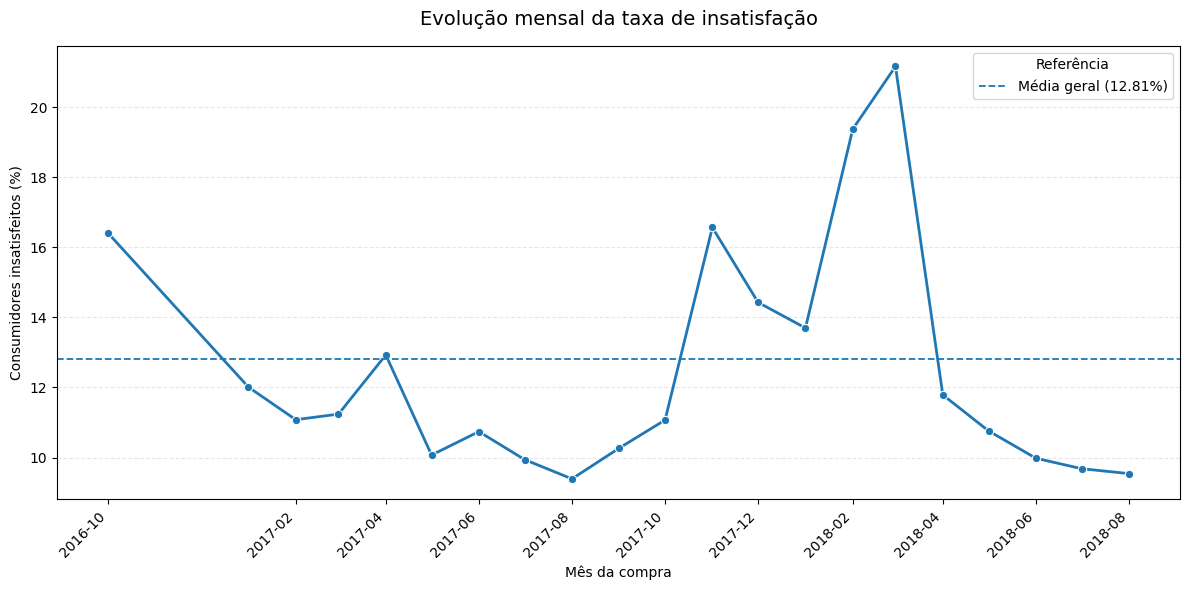

In [ ]:
# Evolução mensal da taxa de insatisfação

# Para a análise visual principal, considerar meses com
# volume mínimo de 100 pedidos avaliados
evolucao_mensal_grafico = (
    evolucao_mensal[
        evolucao_mensal['quantidade_pedidos'] >= 100
    ]
    .copy()
)

# Converter o período para data para manter a ordem cronológica
evolucao_mensal_grafico['data_mes'] = (
    evolucao_mensal_grafico['mes_compra']
    .dt.to_timestamp()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=evolucao_mensal_grafico,
    x='data_mes',
    y='taxa_insatisfacao',
    marker='o',
    linewidth=2
)

# Média geral de insatisfação como referência
taxa_geral = (
    df['insatisfeito']
    .dropna()
    .mean() * 100
)

ax.axhline(
    y=taxa_geral,
    linestyle='--',
    linewidth=1.3,
    label=f'Média geral ({taxa_geral:.2f}%)'
)

ax.set_title(
    'Evolução mensal da taxa de insatisfação',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Mês da compra')
ax.set_ylabel('Consumidores insatisfeitos (%)')

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

# Melhorar os rótulos do eixo X
ax.set_xticks(
    evolucao_mensal_grafico['data_mes'][::2]
)

ax.set_xticklabels(
    evolucao_mensal_grafico['mes'][::2],
    rotation=45,
    ha='right'
)

ax.legend(title='Referência')

plt.tight_layout()
plt.show()

### Interpretação da evolução temporal

A taxa de insatisfação apresentou variações relevantes ao longo do período analisado.

Para a visualização da tendência mensal, foram considerados apenas meses com pelo menos 100 pedidos avaliados, evitando que períodos com volume extremamente reduzido distorcessem a interpretação.

Durante grande parte de 2017, a taxa permaneceu próxima ou abaixo da média geral da base. A partir de novembro de 2017, entretanto, observa-se um aumento da insatisfação, com taxa de **16,57%** naquele mês.

O crescimento torna-se ainda mais evidente no início de 2018. Em fevereiro, a taxa atingiu **19,38%**, alcançando o maior valor entre os meses de volume relevante em março de 2018, com **21,17%** de consumidores insatisfeitos.

Após esse pico, ocorreu uma redução expressiva: a taxa caiu para **11,79% em abril de 2018** e permaneceu abaixo da média geral nos meses seguintes, chegando a **9,54% em agosto de 2018**.

Esse comportamento indica que a insatisfação não permaneceu constante ao longo do tempo e sugere a existência de fatores temporais ou operacionais associados ao aumento observado entre o final de 2017 e o primeiro trimestre de 2018.

### Investigação do pico de insatisfação no início de 2018

A análise temporal identificou um aumento expressivo da taxa de insatisfação entre o final de 2017 e o primeiro trimestre de 2018, com pico de 21,17% em março de 2018.

Para aprofundar esse resultado, serão analisados indicadores logísticos ao longo do mesmo período, buscando verificar se o aumento da insatisfação ocorreu simultaneamente a mudanças no desempenho das entregas.

Serão observados:

- percentual de pedidos entregues com atraso;
- tempo médio de entrega;
- taxa mensal de insatisfação.

A análise busca identificar padrões simultâneos entre os indicadores, sem estabelecer relação causal entre eles.

In [ ]:
# Evolução mensal dos indicadores logísticos

logistica_mensal = (
    dados_temporais
    .groupby('mes_compra')
    .agg(
        quantidade_pedidos=('order_id', 'count'),
        taxa_insatisfacao=('insatisfeito', 'mean'),
        taxa_atraso=('atrasado', 'mean'),
        tempo_entrega_medio=('tempo_entrega_dias', 'mean')
    )
    .reset_index()
)

# Converter proporções para percentual
logistica_mensal['taxa_insatisfacao'] = (
    logistica_mensal['taxa_insatisfacao'] * 100
)

logistica_mensal['taxa_atraso'] = (
    logistica_mensal['taxa_atraso'] * 100
)

# Arredondamento
logistica_mensal[
    [
        'taxa_insatisfacao',
        'taxa_atraso',
        'tempo_entrega_medio'
    ]
] = (
    logistica_mensal[
        [
            'taxa_insatisfacao',
            'taxa_atraso',
            'tempo_entrega_medio'
        ]
    ].round(2)
)

# Manter meses com volume suficiente
logistica_mensal_relevante = (
    logistica_mensal[
        logistica_mensal['quantidade_pedidos'] >= 100
    ]
    .copy()
)

logistica_mensal_relevante['mes'] = (
    logistica_mensal_relevante['mes_compra']
    .astype(str)
)

display(
    logistica_mensal_relevante[
        [
            'mes',
            'quantidade_pedidos',
            'taxa_insatisfacao',
            'taxa_atraso',
            'tempo_entrega_medio'
        ]
    ]
)

,mes,quantidade_pedidos,taxa_insatisfacao,taxa_atraso,tempo_entrega_medio
1,2016-10,262,16.41,0.76,19.31
3,2017-01,741,12.01,2.97,12.58
4,2017-02,1643,11.08,2.80,12.95
5,2017-03,2527,11.24,5.50,12.95
6,2017-04,2290,12.93,7.73,14.84
7,2017-05,3517,10.07,3.44,11.26
8,2017-06,3111,10.74,3.79,11.99
9,2017-07,3842,9.94,3.36,11.55
10,2017-08,4165,9.39,3.31,11.15
11,2017-09,4118,10.27,5.12,11.82


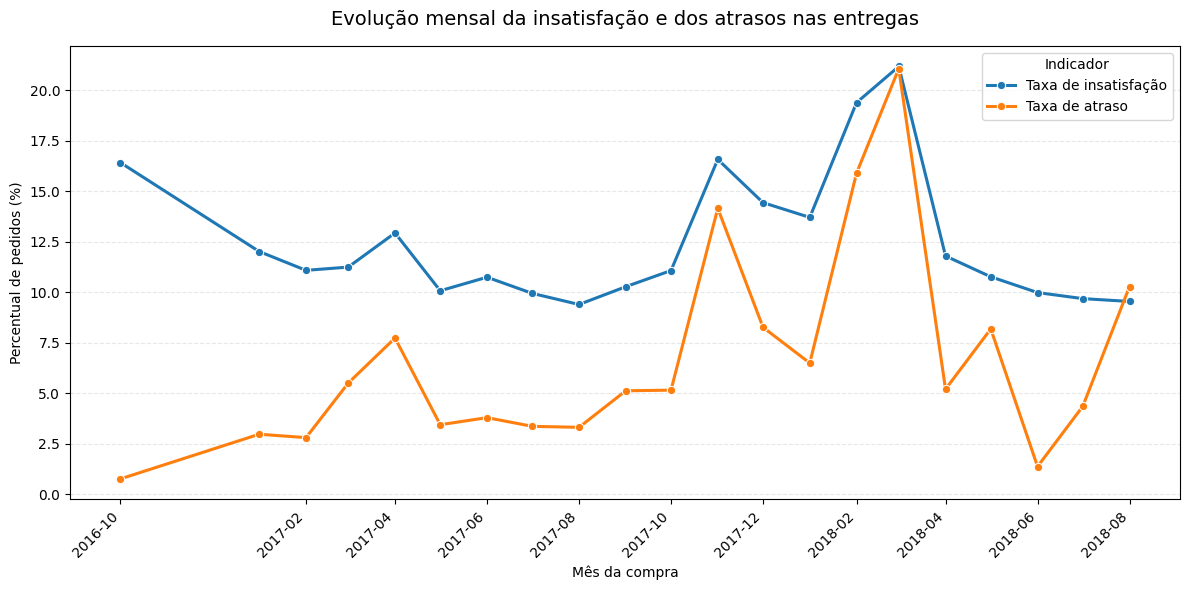

In [ ]:
# Evolução mensal da insatisfação e dos atrasos

grafico_logistica = logistica_mensal_relevante.copy()

grafico_logistica['data_mes'] = (
    grafico_logistica['mes_compra']
    .dt.to_timestamp()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=grafico_logistica,
    x='data_mes',
    y='taxa_insatisfacao',
    marker='o',
    linewidth=2.2,
    label='Taxa de insatisfação'
)

sns.lineplot(
    data=grafico_logistica,
    x='data_mes',
    y='taxa_atraso',
    marker='o',
    linewidth=2.2,
    label='Taxa de atraso',
    ax=ax
)

ax.set_title(
    'Evolução mensal da insatisfação e dos atrasos nas entregas',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Mês da compra')
ax.set_ylabel('Percentual de pedidos (%)')

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

# Mostrar rótulos a cada dois meses
ax.set_xticks(
    grafico_logistica['data_mes'][::2]
)

ax.set_xticklabels(
    grafico_logistica['mes'][::2],
    rotation=45,
    ha='right'
)

ax.legend(title='Indicador')

plt.tight_layout()
plt.show()

### Interpretação dos indicadores logísticos no período crítico

A investigação temporal evidencia que os períodos de maior insatisfação coincidiram com uma deterioração dos indicadores logísticos.

Em novembro de 2017, a taxa de insatisfação aumentou para **16,57%**, enquanto a taxa de atraso atingiu **14,15%**. Um comportamento ainda mais expressivo ocorreu no início de 2018.

Em fevereiro de 2018, a insatisfação alcançou **19,38%**, acompanhada por uma taxa de atraso de **15,89%** e tempo médio de entrega de **16,91 dias**. Em março, mês com a maior taxa de insatisfação do período relevante (**21,17%**), a taxa de atraso também atingiu seu maior nível, **21,06%**, enquanto o tempo médio de entrega permaneceu elevado em **16,22 dias**.

Em abril de 2018, observa-se uma melhora simultânea dos indicadores: a taxa de atraso caiu para **5,20%**, o tempo médio de entrega para **11,46 dias** e a insatisfação para **11,79%**.

O comportamento conjunto dos indicadores reforça a associação identificada anteriormente entre desempenho logístico e satisfação do consumidor. Os resultados mostram que períodos de pior desempenho das entregas coincidiram com maiores taxas de insatisfação, embora essa análise observacional não permita estabelecer causalidade.

## 9. Principais insights da análise exploratória

A análise exploratória permitiu identificar padrões relevantes associados à insatisfação dos consumidores e compreender melhor as características da variável-alvo.

### Principais resultados

**1. A insatisfação representa uma classe minoritária**

Entre os pedidos avaliados, **12,81% dos consumidores foram classificados como insatisfeitos**, enquanto 87,19% foram classificados como não insatisfeitos. Esse desbalanceamento deverá ser considerado na etapa de modelagem preditiva.

**2. O desempenho logístico apresentou a associação mais expressiva com a insatisfação**

A taxa de insatisfação foi de apenas **9,22% nos pedidos entregues dentro do prazo**, mas atingiu **54,07% entre os pedidos atrasados**.

Além disso, consumidores insatisfeitos apresentaram tempo médio de entrega de **20,21 dias**, frente a **11,39 dias** entre os não insatisfeitos.

**3. A antecedência em relação ao prazo estimado também diferencia os grupos**

Os pedidos de consumidores não insatisfeitos foram entregues, em média, **12,21 dias antes do prazo estimado**, enquanto entre os insatisfeitos a antecedência média foi de apenas **4,43 dias**.

**4. Pedidos associados à insatisfação apresentaram valores financeiros médios superiores**

O valor total médio foi de **R\$ 187,60** entre consumidores insatisfeitos e **R\$ 155,45** entre não insatisfeitos. Também foram observados valores médios superiores de produtos e frete entre os consumidores insatisfeitos.

**5. A complexidade dos pedidos apresentou diferenças menos expressivas**

A quantidade média de itens foi ligeiramente superior entre consumidores insatisfeitos, mas a mediana permaneceu em **1 item** nos dois grupos. A quantidade de vendedores apresentou diferenças ainda menores.

**6. Existem diferenças relevantes entre categorias de produtos**

Entre as categorias com pelo menos 100 pedidos avaliados, **Fashion Roupa Masculina, Móveis Escritório e Áudio** apresentaram as maiores taxas de insatisfação.

A categoria **Cama Mesa Banho** também se destacou pelo impacto em volume, registrando **1.438 consumidores insatisfeitos em 9.090 pedidos avaliados**.

**7. A insatisfação apresentou diferenças geográficas**

Entre os estados com volume relevante, **Alagoas, Maranhão e Sergipe** apresentaram as maiores taxas de insatisfação.

O **Rio de Janeiro** merece destaque por combinar uma taxa elevada de **18,33%** com um volume expressivo de **12.211 pedidos avaliados**.

**8. Foram identificados períodos críticos de insatisfação**

A taxa de insatisfação aumentou significativamente no final de 2017 e início de 2018, atingindo **21,17% em março de 2018**.

A investigação desse período mostrou uma deterioração simultânea dos indicadores logísticos. Em março de 2018, a taxa de atraso atingiu **21,06%**, reforçando a associação observada entre desempenho das entregas e insatisfação.

### Síntese

Os resultados da análise exploratória indicam que **as características relacionadas à logística constituem os sinais mais fortes associados à insatisfação dos consumidores nesta base**.

Aspectos financeiros, categoria do produto, localização geográfica e características do pedido também apresentaram diferenças entre os grupos e poderão contribuir para a etapa preditiva quando analisados conjuntamente.

Os resultados apresentados são de natureza descritiva e representam associações observadas nos dados, não devendo ser interpretados isoladamente como relações de causalidade.

## 10. Conclusão e próximos passos

A análise exploratória permitiu compreender a distribuição da variável-alvo e identificar características associadas à insatisfação dos consumidores.

Os resultados evidenciaram principalmente a relevância das variáveis relacionadas ao desempenho logístico, além de diferenças associadas às características financeiras, categorias de produtos, localização dos consumidores e período da compra.

Esses achados fornecem direcionamento para a próxima etapa do projeto, na qual será desenvolvida uma abordagem preditiva para identificar pedidos com maior probabilidade de insatisfação.

Na etapa seguinte, serão realizadas a seleção e preparação das variáveis explicativas, a separação dos dados de treino e teste, o treinamento de modelos de classificação e a avaliação de desempenho com métricas adequadas ao desbalanceamento da variável-alvo.

In [ ]:
# Validação final para a próxima etapa

print("ANÁLISE EXPLORATÓRIA CONCLUÍDA")
print("-" * 40)

print(f"Pedidos na base analítica: {len(df):,}")
print(
    f"Pedidos com avaliação: "
    f"{df['insatisfeito'].notna().sum():,}"
)

print(
    f"Consumidores insatisfeitos: "
    f"{int(df['insatisfeito'].sum()):,}"
)

print(
    f"Taxa de insatisfação: "
    f"{df['insatisfeito'].dropna().mean() * 100:.2f}%"
)

print("-" * 40)
print("Base pronta para a etapa de modelagem.")

ANÁLISE EXPLORATÓRIA CONCLUÍDA
----------------------------------------
Pedidos na base analítica: 96,470
Pedidos com avaliação: 95,824
Consumidores insatisfeitos: 12,272
Taxa de insatisfação: 12.81%
----------------------------------------
Base pronta para a etapa de modelagem.
